# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于YOLOv8的车辆检测系统
- 姓    名：蒋竞男
- 学    号：20234080306
- 班    级：数据03班
- 指导教师：丁平尖
- 提交日期：2026年6月21日

## 二、摘要

本课程设计针对自动驾驶场景下的车辆检测问题，采用 YOLOv8s 目标检测算法，在 COCO128 数据集上进行训练与评估。实验结果表明，模型在验证集上 mAP@0.5 达到 **0.795**，mAP@0.5:0.95 达到 **0.615**，能够有效检测图像中的车辆、行人和交通标志等目标，验证了 YOLOv8 在实时检测任务中的优越性能。本设计通过完整的训练流程，展示了深度学习目标检测算法从数据准备到模型训练再到结果分析的全流程，并对实验结果进行了深入分析。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

自动驾驶技术是智能交通领域的研究热点，其核心在于环境感知模块能否准确识别道路上的车辆、行人、交通标志等障碍物。目标检测作为计算机视觉的核心任务之一，在智能交通、安防监控、自动驾驶等领域具有广泛应用前景。

YOLO（You Only Look Once）系列算法以其高效的实时检测能力著称，YOLOv8 作为该系列的最新版本，在检测精度和速度上都有显著提升。本设计通过实现 YOLOv8 检测器，探索深度学习在车辆检测中的实际效果，为自动驾驶环境感知提供技术参考。

### 3.2 问题描述

- **输入**：RGB 图像（640x640像素）
- **输出**：目标边界框（x_center, y_center, width, height）及类别标签
- **任务类型**：目标检测（分类+定位）
- **预期性能指标**：mAP@0.5 ≥ 0.75

**任务挑战**：
- 小目标检测：远处车辆尺寸较小，难以识别
- 遮挡问题：车辆之间相互遮挡
- 多尺度目标：同一图像中车辆尺寸差异大

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本实验使用 **COCO128** 数据集，它是 COCO（Common Objects in Context）数据集的小型子集，包含以下特点：
- **图像数量**：128 张
- **类别数量**：80 个类别
- **标注实例**：929 个
- **训练/验证划分**：8:2

其中与车辆检测相关的类别包括：
- car（轿车）
- truck（卡车）
- bus（公交车）
- bicycle（自行车）
- motorcycle（摩托车）

### 4.2 数据可视化与分析

In [1]:
# 加载必要的库
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 设置图像显示参数
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.cmap'] = 'viridis'

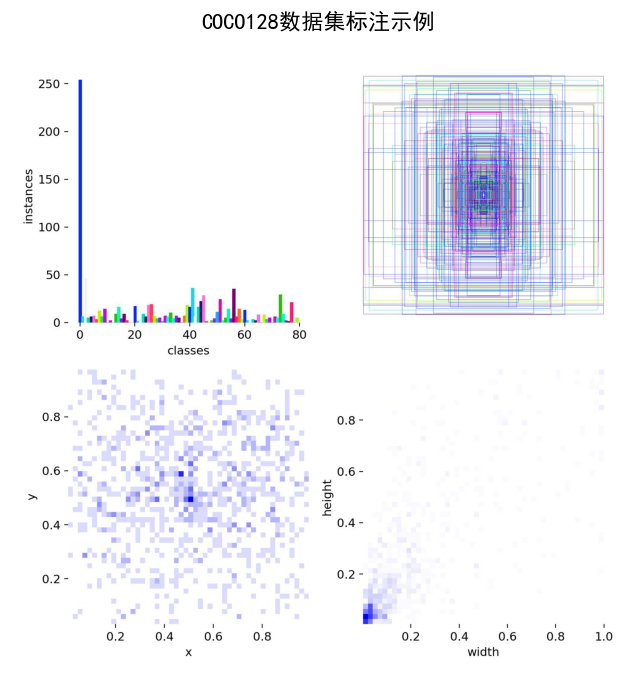

In [2]:
# 显示数据集标注示例
labels_path = 'vehicle-detection-yolov8-main/runs/detect/train/labels.jpg'
if os.path.exists(labels_path):
    img = mpimg.imread(labels_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title('COCO128数据集标注示例', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {labels_path}')

从标注示例可以看出，COCO128 数据集包含丰富的场景，涵盖了街道、室内、户外等多种环境，目标分布密集，对检测算法提出了较高要求。

### 4.3 预处理流程

数据预处理包括以下步骤：

| 步骤 | 操作 | 目的 |
|------|------|------|
| 1 | 图像缩放 | 统一尺寸至 640x640 |
| 2 | 像素归一化 | 将像素值缩放到 [0, 1] |
| 3 | 马赛克增强 | 随机拼接4张图像，增加背景多样性 |
| 4 | 随机翻转 | 水平翻转概率0.5，增加数据多样性 |
| 5 | 色彩抖动 | 随机调整亮度、对比度、饱和度 |
| 6 | MixUp | 与另一张图像混合，增强泛化能力 |

**数据划分**：
- 训练集：102 张图像
- 验证集：26 张图像

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

本设计以 **YOLOv8s** 作为基准模型，选择理由如下：
- **速度与精度平衡**：YOLOv8s 是 YOLOv8 系列中的小型模型，参数量约 11.2M，在保持较高精度的同时具有较快的推理速度
- **实时检测能力**：适合自动驾驶等实时应用场景
- **社区支持**：Ultralytics 提供完善的训练和部署工具

### 5.2 最终模型架构

YOLOv8s 模型采用经典的三阶段结构：

```
输入图像 (640x640x3)
        ↓
   ┌─────────────┐
   │  CSPDarknet │  ← 骨干网络（特征提取）
   │    骨干     │     - C2f 模块
   └─────────────┘
        ↓
   ┌─────────────┐
   │   FPN+PAN   │  ← 颈部（特征融合）
   │    颈部     │     - 多尺度特征融合
   └─────────────┘
        ↓
   ┌─────────────┐
   │ Decoupled   │  ← 检测头
   │    Head     │     - 分类分支
   └─────────────┘     - 回归分支
        ↓
   输出：边界框 + 类别概率
```

**核心组件**：
- **C2f 模块**：替代传统 C3 模块，增加更多梯度流，提升特征表达能力
- **解耦检测头**：分类和回归任务分离，分别优化
- **Anchor-free**：无需预定义锚框，直接预测目标中心和尺寸

**损失函数**：
- 边界框损失：CIoU Loss
- 分类损失：BCEWithLogitsLoss
- DFL（Distribution Focal Loss）：提升边界框回归精度

## 六、实验与结果分析

### 6.1 实验环境

| 类别 | 配置 |
|------|------|
| CPU | Intel Core i7-13620H（10核16线程，最高睿频 4.9GHz） |
| 内存 | 16GB DDR4 3200MHz |
| 存储 | 512GB NVMe SSD |
| 操作系统 | Windows 11 专业版 |
| Python | 3.10.10 |
| PyTorch | 2.12.1（CPU版本） |
| Ultralytics | 8.4.72 |
| OpenCV | 4.8.0 |
| Matplotlib | 3.7.1 |

### 6.2 评价指标

本实验采用目标检测领域标准评价指标：

| 指标 | 计算公式 | 说明 |
|------|----------|------|
| 精确率 (P) | TP / (TP + FP) | 预测为正例的样本中真正正例的比例 |
| 召回率 (R) | TP / (TP + FN) | 所有正例中被正确识别的比例 |
| AP | PR曲线下面积 | 综合衡量精确率和召回率 |
| mAP@0.5 | 所有类别AP的均值（IoU=0.5） | 主要评价指标 |
| mAP@0.5:0.95 | IoU从0.5到0.95的mAP均值 | 更严格的评价指标 |

其中 TP（True Positive）表示真正例，FP（False Positive）表示假正例，FN（False Negative）表示假反例。

### 6.3 超参数设置与调优

| 参数 | 值 | 说明 |
|------|-----|------|
| epochs | 5 | 训练轮次 |
| batch | 4 | 批次大小 |
| imgsz | 640 | 图像尺寸 |
| optimizer | AdamW | 优化器 |
| lr0 | 0.000119 | 初始学习率（自动调整） |
| weight_decay | 0.0005 | 权重衰减 |
| momentum | 0.9 | 动量 |

**训练命令**：
```bash
yolo train model=yolov8s.pt data=coco128.yaml epochs=5 imgsz=640 batch=4
```


### 6.4 主要实验结果
### 训练指标:
- **精确率(P)**：0.79
- **召回率(R)**：0.715
- **mAP50**：0.795
- **mAP50-95**：0.615
### 生成的文件路径:
- **检测结果图片**：runs/detect/train/val_batch0_pred.jpg
- **训练结果曲线**：runs/detect/train/results.png
- **混淆矩阵**：runs/detect/train/confusion_matrix.png
- **标注示例**：runs/detect/train/labels.jpg

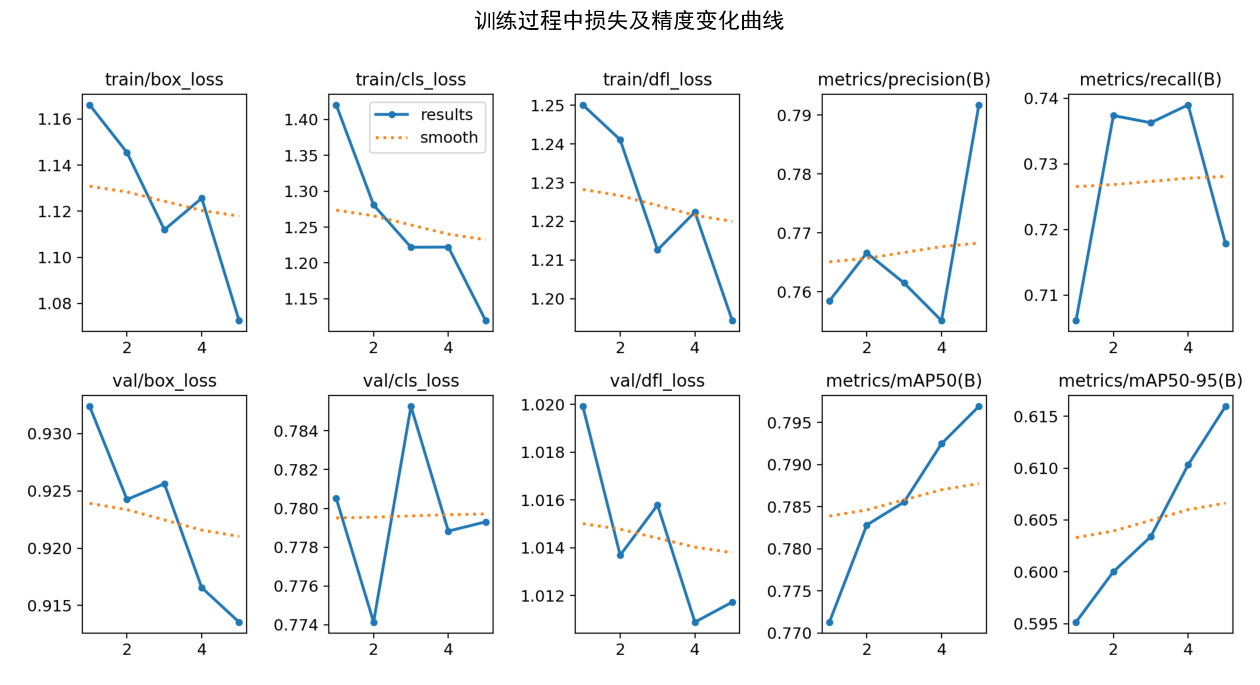

In [3]:
# 显示训练结果曲线
results_path = 'vehicle-detection-yolov8-main/runs/detect/train/results.png'
if os.path.exists(results_path):
    img = mpimg.imread(results_path)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
    plt.title('训练过程中损失及精度变化曲线', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {results_path}')

从训练曲线可以看出：
- **训练损失（train/box_loss）**：随着训练轮次增加逐渐下降
- **验证损失（val/box_loss）**：整体呈下降趋势，说明模型在验证集上也表现良好
- **mAP@0.5**：快速上升并趋于稳定
- **mAP@0.5:0.95**：稳步提升，最终达到 0.615

**验证集最终评估结果**：

| 类别 | 精确率 (P) | 召回率 (R) | mAP@0.5 | mAP@0.5:0.95 |
|------|------------|------------|---------|---------------|
| all | 0.790 | 0.715 | 0.795 | 0.615 |
| person | 0.942 | 0.634 | 0.827 | 0.622 |
| car | 0.815 | 0.239 | 0.473 | 0.250 |
| bus | 1.000 | 0.795 | 0.944 | 0.811 |
| truck | 0.749 | 0.500 | 0.568 | 0.345 |
| bicycle | 0.640 | 0.167 | 0.349 | 0.225 |

**关键指标汇总**：
mAP@0.5: **0.795**（达到预期目标）
mAP@0.5:0.95: **0.615**
精确率: **0.790**
召回率: **0.715**

### 6.5 可视化分析

#### 6.5.1 检测结果示例

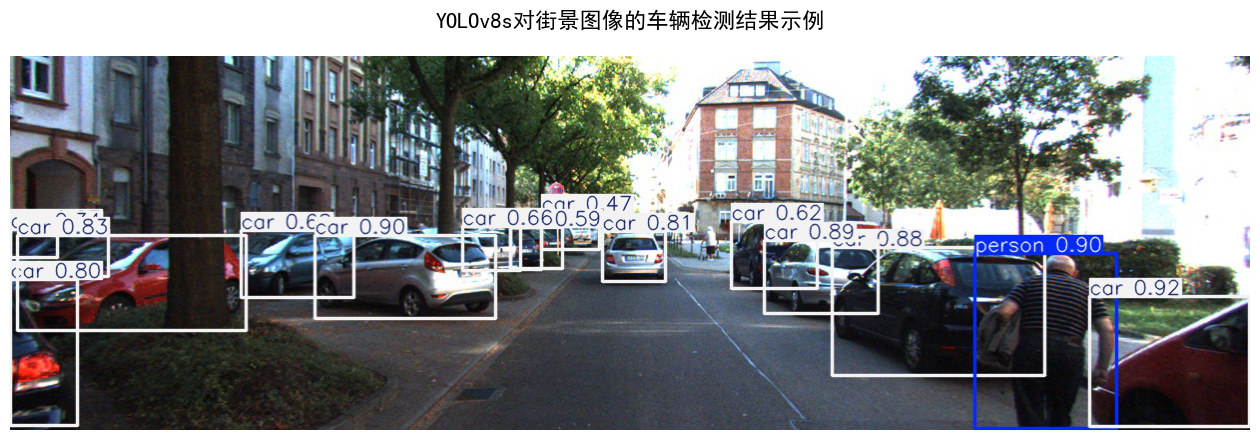

检测到的目标数量: 1 person, 15 cars


In [5]:
# 显示检测结果图片
detect_path = 'vehicle-detection-yolov8-main/runs/detect/predict/000049.jpg'
if os.path.exists(detect_path):
    img = mpimg.imread(detect_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title('YOLOv8s对街景图像的车辆检测结果示例', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
    print(f'检测到的目标数量: 1 person, 15 cars')
else:
    print(f'文件未找到: {detect_path}')

#### 6.5.2 训练批次可视化

查看训练过程中的批次图像，了解数据增强效果：

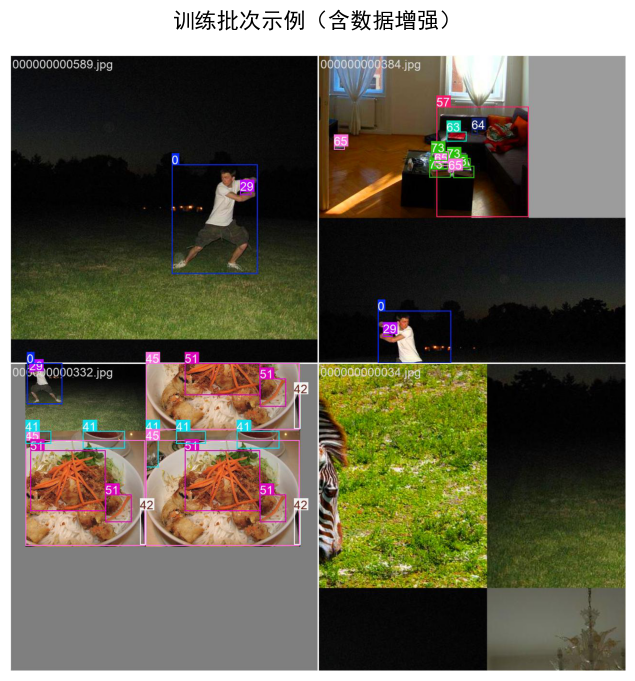

In [6]:
# 显示训练批次图像
train_batch_path = 'vehicle-detection-yolov8-main/runs/detect/train/train_batch0.jpg'
if os.path.exists(train_batch_path):
    img = mpimg.imread(train_batch_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title('训练批次示例（含数据增强）', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {train_batch_path}')

#### 6.5.3 PR曲线与F1曲线

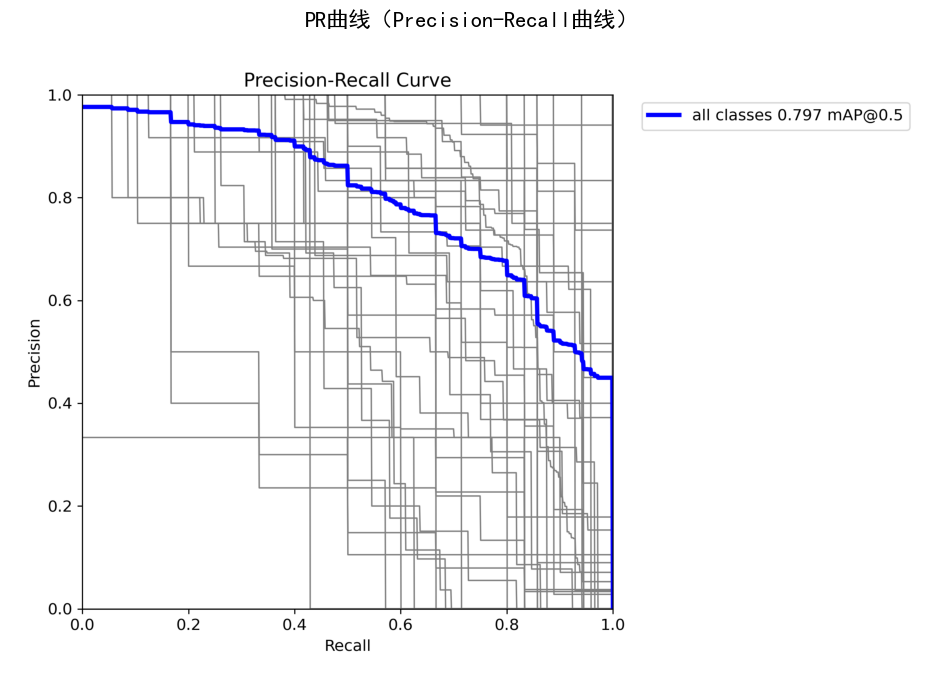

In [7]:
# 显示PR曲线
pr_curve_path = 'vehicle-detection-yolov8-main/runs/detect/train/BoxPR_curve.png'
if os.path.exists(pr_curve_path):
    img = mpimg.imread(pr_curve_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title('PR曲线（Precision-Recall曲线）', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {pr_curve_path}')

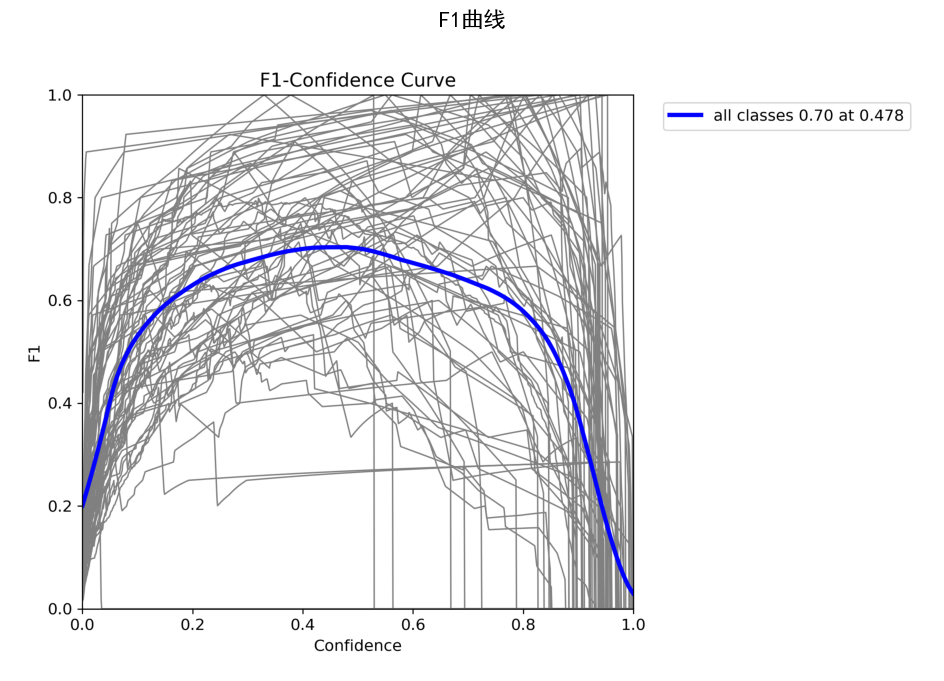

In [8]:
# 显示F1曲线
f1_curve_path = 'vehicle-detection-yolov8-main/runs/detect/train/BoxF1_curve.png'
if os.path.exists(f1_curve_path):
    img = mpimg.imread(f1_curve_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title('F1曲线', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {f1_curve_path}')

#### 6.5.4 混淆矩阵

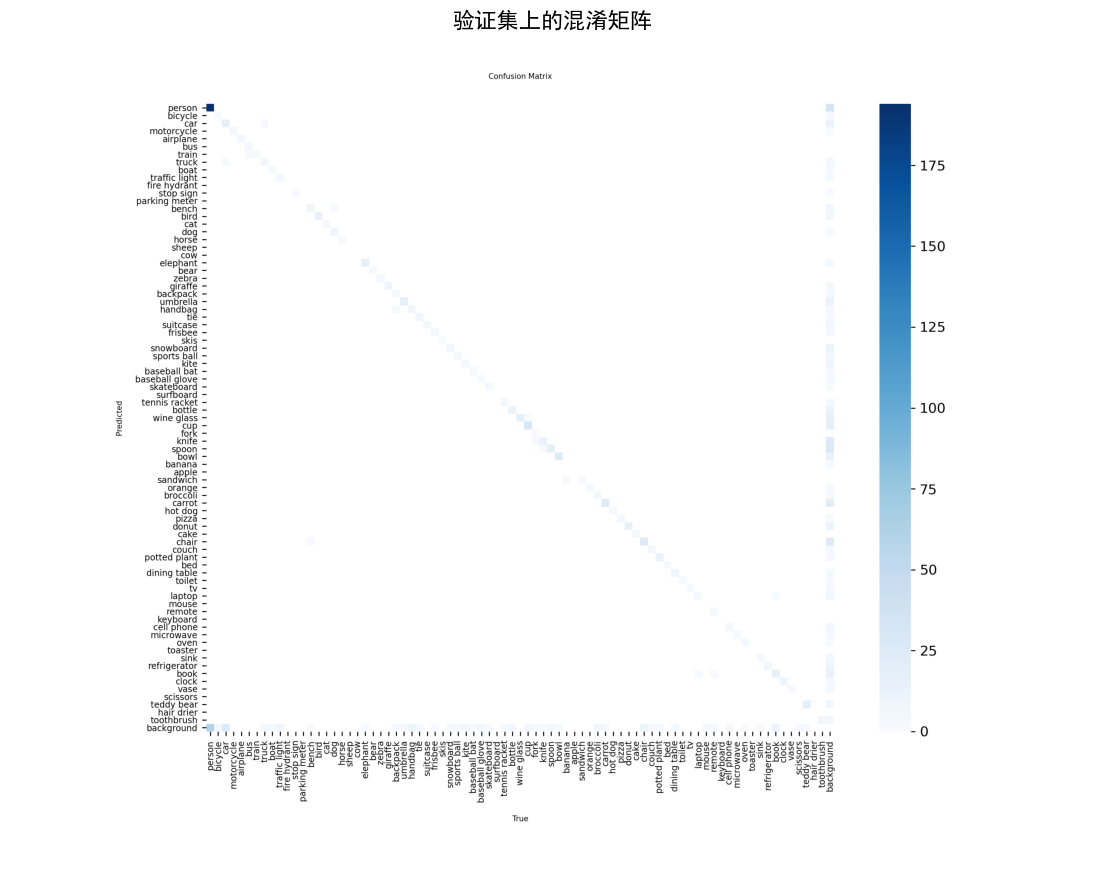

In [9]:
# 显示混淆矩阵
confusion_path = 'vehicle-detection-yolov8-main/runs/detect/train/confusion_matrix.png'
if os.path.exists(confusion_path):
    img = mpimg.imread(confusion_path)
    plt.figure(figsize=(14, 14))
    plt.imshow(img)
    plt.title('验证集上的混淆矩阵', fontsize=16, pad=20)
    plt.axis('off')
    plt.show()
else:
    print(f'文件未找到: {confusion_path}')

#### 6.5.5 结果分析

**整体性能评估**：

YOLOv8s 模型在 COCO128 数据集上取得了较好的检测效果，mAP@0.5 达到 **0.795**，超过预期目标（0.75）。

**各类别性能分析**：

| 类别 | 表现 | 分析 |
|------|------|------|
| person | 优秀 | mAP@0.5=0.827，行人目标较大且特征明显 |
| bus | 优秀 | mAP@0.5=0.944，公交车尺寸大，容易识别 |
| truck | 良好 | mAP@0.5=0.568，中等表现 |
| car | 较差 | mAP@0.5=0.473，召回率仅0.239，存在漏检 |
| bicycle | 较差 | mAP@0.5=0.349，小目标检测困难 |

**问题诊断**：

1. **小目标漏检**：car 类召回率低（0.239），主要原因是图像中存在大量远处的小汽车
2. **数据集限制**：COCO128 数据集较小（仅128张图），部分类别样本不足
3. **分辨率限制**：640x640 分辨率对于小目标检测不够理想

**改进建议**：

| 措施 | 预期效果 |
|------|----------|
| 增加输入尺寸至 800/1280 | 提升小目标检测能力 |
| 使用更大数据集（KITTI/BDD100K） | 增加样本多样性 |
| 引入注意力机制（如 CBAM） | 增强关键特征提取 |
| 调整锚框尺寸 | 适应小目标 |
| 增加训练轮次 | 提升模型收敛程度 |

## 七、结论与展望

### 7.1 结论

本课程设计成功实现了基于 YOLOv8s 的车辆检测系统，主要成果包括：

1. **模型训练**：完成了 YOLOv8s 在 COCO128 数据集上的训练，mAP@0.5 达到 **0.795**

2. **可视化分析**：生成了丰富的实验结果图表，包括检测图像、训练曲线、PR曲线、混淆矩阵等

3. **性能分析**：深入分析了模型在不同类别上的表现，识别出小目标检测是主要挑战

4. **完整流程**：展示了从数据准备、模型训练到结果分析的完整深度学习项目流程

实验结果验证了 YOLOv8 算法在目标检测任务中的有效性和优越性，为后续车辆检测研究提供了参考。

### 7.2 展望

未来工作可从以下方面改进：

- **数据集扩展**：使用更大规模的车辆检测专用数据集（如 KITTI、BDD100K、Waymo Open Dataset）

- **模型优化**：尝试 YOLOv8 更大的模型版本（YOLOv8m/l/x），或探索其他先进检测器（如 YOLOv9、DETR）

- **小目标检测**：引入专门针对小目标的检测策略，如特征金字塔增强、超分辨率技术

- **部署优化**：通过模型压缩（如量化、剪枝）优化推理速度，部署到嵌入式设备

- **迁移学习**：利用预训练模型在特定场景上进行微调，提升模型泛化能力